# Explore: political / mandate data

Loads `stateparl_v3_mandates.parquet` (v3 mandates table, `DATA_ROOT/raw/stateparl_v3_parquet/`) and describes
affiliation coverage, how well mandates link to StatePol (`statepol_id`), and AfD mandates per period.

`DATA_ROOT` comes from Google Drive in Colab and from the repo's `.env` locally.

In [1]:
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_ROOT = "/content/drive/My Drive/my_projects/M.A. Parliament/Code and Data/data"
else:
    if "DATA_ROOT" not in os.environ:
        from dotenv import load_dotenv, find_dotenv
        load_dotenv(find_dotenv(usecwd=True))
    DATA_ROOT = os.environ.get("DATA_ROOT", "")

print("DATA_ROOT:", DATA_ROOT)
assert DATA_ROOT and os.path.isdir(DATA_ROOT), f"DATA_ROOT not set or missing: {DATA_ROOT!r}"


DATA_ROOT: /Users/anna/Library/CloudStorage/GoogleDrive-anle.werner.01@gmail.com/My Drive/my_projects/M.A. Parliament/Code and Data/data


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW = Path(DATA_ROOT) / "raw"
V3  = RAW / "stateparl_v3_parquet"
PROC = Path(DATA_ROOT) / "processed"

## Load mandates table

In [3]:
mandates = pd.read_parquet(V3 / "stateparl_v3_mandates.parquet")
print(mandates.shape)
mandates.head()

(17543, 6)


,mandate_id,state,period,affiliation,speaker_mandate,statepol_id
0,bb_3_cdu_bartsch,bb,3,cdu,Bartsch,/wiki/Uwe_Bartsch-bb-3
1,bb_3_cdu_blechinger,bb,3,cdu,Blechinger,/wiki/Beate_Blechinger-bb-3
2,bb_3_cdu_boruhrowski,bb,3,cdu,Boruhrowski,NaN
3,bb_3_cdu_dehn,bb,3,cdu,Dehn,NaN
4,bb_3_cdu_dombrowski,bb,3,cdu,Dombrowski,/wiki/Dieter_Dombrowski-bb-3


In [4]:
mandates.dtypes

mandate_id           str
state                str
period             int64
affiliation          str
speaker_mandate      str
statepol_id          str
dtype: object

## Coverage: states, periods, affiliations

In [5]:
print("States:", sorted(mandates["state"].unique()))
print("Periods per state:")
mandates.groupby("state")["period"].agg(["min", "max", "nunique"])

States: ['bb', 'be', 'bw', 'by', 'hb', 'he', 'hh', 'mv', 'ni', 'nw', 'rp', 'sh', 'sl', 'sn', 'st', 'th']
Periods per state:


,min,max,nunique
state,,,
bb,3,8,6
be,14,19,6
bw,12,17,6
by,14,19,6
hb,15,21,7
he,16,21,6
hh,16,22,7
mv,3,8,6
ni,14,19,6


In [6]:
mandates["affiliation"].value_counts()

affiliation
cdu    4120
spd    3918
gov    2168
grn    1572
oth    1211
lin     818
fdp     710
pre     709
afd     663
csu     569
pds     391
ind     163
frw     118
ijn      99
pir      47
bsw      46
pro      45
npd      39
dvu      28
ssw      23
rgn      17
rep      14
büd      13
fvp      13
biw       9
bmv       5
lkr       4
bft       3
bbr       2
lfm       2
mrf       2
bag       2
Name: count, dtype: int64

## `statepol_id` completeness per mandate

Not every mandate resolves to a StatePol wiki entry. Share missing overall and by state, counting each mandate once.

In [7]:
missing_rate = mandates["statepol_id"].isna().mean()
print(f"Overall missing statepol_id: {missing_rate:.1%}")

mandates.groupby("state")["statepol_id"].apply(lambda s: s.isna().mean()).sort_values(ascending=False).apply(lambda x: f"{x:.1%}")

Overall missing statepol_id: 34.1%


state
hb    52.0%
he    47.2%
bb    46.9%
th    45.3%
by    38.4%
sn    37.1%
sl    35.4%
be    35.3%
rp    29.6%
ni    29.0%
st    28.4%
hh    28.2%
mv    26.0%
bw    25.6%
sh    24.1%
nw    21.5%
Name: statepol_id, dtype: str

## Duplicate / sanity checks

In [8]:
print("Duplicate mandate_id:", mandates["mandate_id"].duplicated().sum())
print("Duplicate statepol_id (excl. NaN):", mandates["statepol_id"].dropna().duplicated().sum())

Duplicate mandate_id: 0
Duplicate statepol_id (excl. NaN): 2260


In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

_cwd = Path(".").resolve()
_repo = _cwd if (_cwd / "utils" / "colors.py").exists() else _cwd.parent
if str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))
from utils.colors import AFFILIATION_COLORS, SEQ_BLUES, NAVY, CHROME

plt.rcParams.update({
    "figure.facecolor": CHROME["surface_light"], "axes.facecolor": CHROME["surface_light"],
    "axes.edgecolor": CHROME["baseline"], "axes.labelcolor": CHROME["ink_secondary"],
    "xtick.color": CHROME["ink_secondary"], "ytick.color": CHROME["ink_secondary"],
    "text.color": CHROME["ink_primary"], "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 9,
})
BLUES = LinearSegmentedColormap.from_list("blues", [SEQ_BLUES[k] for k in sorted(SEQ_BLUES)])
BLUES.set_bad("#efeee9")  # no data
OTHER_GREY = "#8a8984"


def heatmap(data, title, fmt="{:.0%}", vmin=0, vmax=1, figsize=(9, 5), annotate=True):
    """Rows x columns heatmap on the sequential blue ramp. Values are printed in each cell,
    or shown on a colour scale if annotate=False. Light grey cells have no data."""
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data.to_numpy(dtype=float), cmap=BLUES, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(data.shape[1]), data.columns, rotation=0)
    ax.set_yticks(range(data.shape[0]), data.index)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.iat[i, j]
            if annotate and pd.notna(v):
                dark = (v - vmin) / (vmax - vmin) > 0.55
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=7,
                        color="white" if dark else CHROME["ink_primary"])
    if not annotate:
        cb = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
        cb.outline.set_visible(False)
        cb.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: fmt.format(v)))
    ax.set_title(title, loc="left", fontsize=10)
    fig.tight_layout()
    plt.show()

## StatePol coverage weighted by speech

Share of speech paragraphs (all affiliations except `nsc`) whose mandate links to StatePol. Unlike the per-mandate rate above,
this weights each mandate by how much it speaks.

In [10]:
paragraphs = pd.read_parquet(
    V3 / "stateparl_v3_paragraphs.parquet",
    columns=["mandate_id", "state", "period", "date", "affiliation"],
)
speech = (paragraphs[paragraphs["affiliation"] != "nsc"]
          .merge(mandates[["mandate_id", "statepol_id"]], on="mandate_id", how="left"))
speech["date"] = pd.to_datetime(speech["date"])
speech["year"] = speech["date"].dt.year
speech["linked"] = speech["statepol_id"].notna()

print(f"Speech paragraphs: {len(speech):,}")
print(f"Linked to StatePol: {speech['linked'].mean():.1%}")

Speech paragraphs: 11,870,906
Linked to StatePol: 73.3%


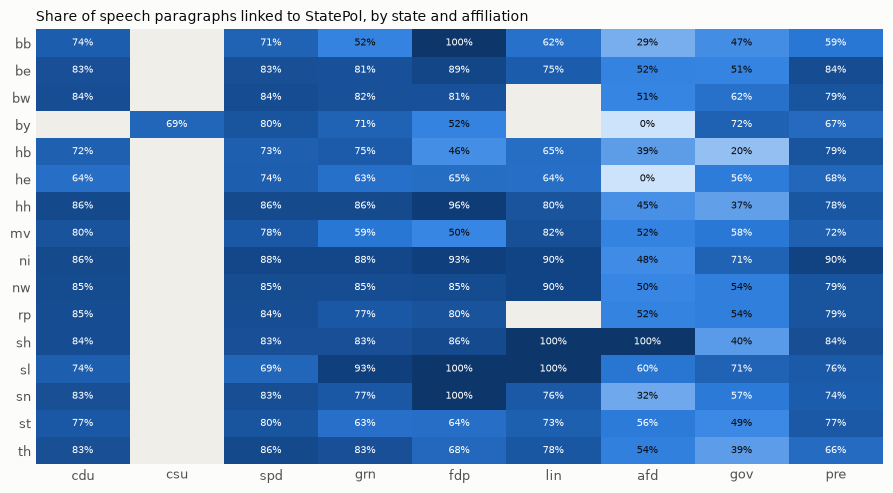

In [11]:
MAJOR = ["cdu", "csu", "spd", "grn", "fdp", "lin", "afd", "gov", "pre"]
by_party = (speech[speech["affiliation"].isin(MAJOR)]
            .pivot_table(index="state", columns="affiliation", values="linked", aggfunc="mean")[MAJOR])
heatmap(by_party, "Share of speech paragraphs linked to StatePol, by state and affiliation")

## Coverage over time

StatePol links stop at a cutoff. From 2019 on, coverage falls for every party and reaches zero by 2023.
Before the cutoff AfD speech is linked as well as other parties' speech, so AfD's low overall rate above comes from timing, not from party.

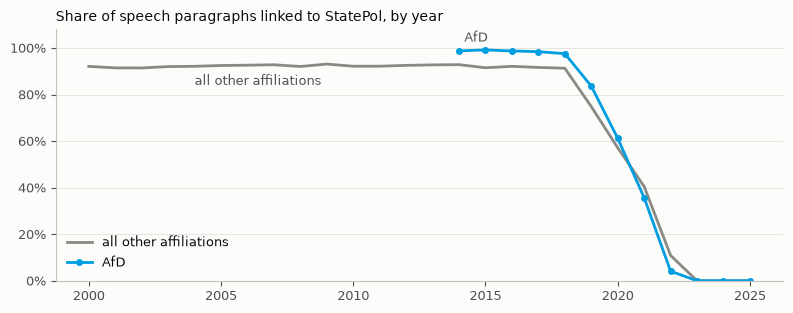

In [12]:
by_year = speech.pivot_table(index="year", columns=speech["affiliation"].eq("afd").map({True: "afd", False: "other"}),
                            values="linked", aggfunc="mean")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(by_year.index, by_year["other"], color=OTHER_GREY, lw=2, label="all other affiliations")
ax.plot(by_year.index, by_year["afd"], color=AFFILIATION_COLORS["afd"], lw=2, marker="o", ms=4, label="AfD")
ax.text(2004, by_year.loc[2004, "other"] - 0.08, "all other affiliations", color=CHROME["ink_secondary"])
ax.text(2014.2, by_year.loc[2014, "afd"] + 0.04, "AfD", color=CHROME["ink_secondary"])
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", color=CHROME["gridline"], lw=0.6)
ax.legend(frameon=False, loc="lower left")
ax.set_title("Share of speech paragraphs linked to StatePol, by year", loc="left", fontsize=10)
fig.tight_layout()
plt.show()

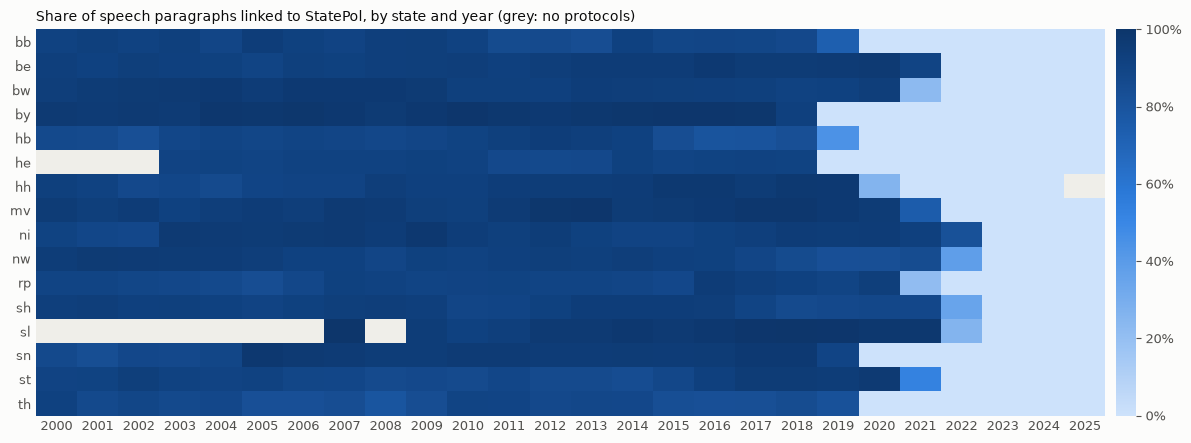

In [13]:
by_state_year = speech.pivot_table(index="state", columns="year", values="linked", aggfunc="mean")
heatmap(by_state_year, "Share of speech paragraphs linked to StatePol, by state and year (grey: no protocols)",
        figsize=(12, 4.5), annotate=False)

In [14]:
afd_dates = pd.read_csv(PROC / "afd_entry_dates.csv", parse_dates=["entry_date", "exit_date"])
parties = speech[speech["affiliation"].isin(["cdu", "csu", "spd", "grn", "fdp", "lin", "afd"])].merge(afd_dates, on="state")
parties["afd_present"] = (
    (parties["date"] >= parties["entry_date"])
    & (parties["exit_date"].isna() | (parties["date"] <= parties["exit_date"]))
)
other = parties[parties["affiliation"] != "afd"]
print(f"Other parties, before AfD entry: {other.loc[~other['afd_present'], 'linked'].mean():.1%} linked")
print(f"Other parties, with AfD present: {other.loc[other['afd_present'], 'linked'].mean():.1%} linked")
print(f"AfD (always present):            {parties.loc[parties['affiliation'] == 'afd', 'linked'].mean():.1%} linked")

Other parties, before AfD entry: 95.3% linked
Other parties, with AfD present: 47.9% linked
AfD (always present):            43.8% linked


## Person-level ID

`statepol_id` identifies a person in one state and period (`/wiki/Uwe_Bartsch-bb-3`). Removing the `-{state}-{period}` suffix
gives one ID per person across periods. Only linked mandates get one.

Persons: 4,924
Persons in more than one state: 2


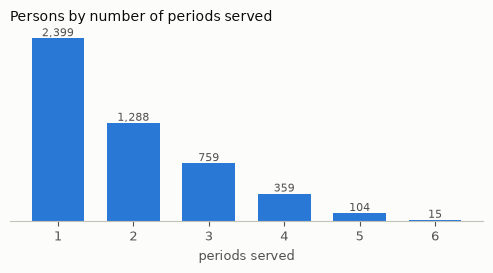

In [15]:
linked = mandates.dropna(subset=["statepol_id"]).copy()
parts = linked["statepol_id"].str.extract(r"^(?P<person_id>.+)-(?P<sp_state>[a-z]{2})-(?P<sp_period>\d+)$")
assert parts["person_id"].notna().all()
assert (parts["sp_state"] == linked["state"]).all()
assert (parts["sp_period"].astype(int) == linked["period"]).all()
linked["person_id"] = parts["person_id"]

print(f"Persons: {linked['person_id'].nunique():,}")
print(f"Persons in more than one state: {(linked.groupby('person_id')['state'].nunique() > 1).sum()}")

served = linked.groupby("person_id")["period"].nunique().value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 2.8))
ax.bar(served.index, served.values, color=NAVY, width=0.7)
for x, y in served.items():
    ax.text(x, y + 30, f"{y:,}", ha="center", color=CHROME["ink_secondary"], fontsize=8)
ax.set_xlabel("periods served")
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_title("Persons by number of periods served", loc="left", fontsize=10)
fig.tight_layout()
plt.show()

Several mandates can share one `statepol_id`. Same affiliation means spelling variants of one name (`Kessel`, `Adolf Kessel`).
Different affiliations mean a second role in the same period, such as `gov` or `pre`, or the catch-all `oth`.

statepol_ids with more than one mandate: 1,924
  same affiliation (name variants): 426
  different affiliations: 1,498


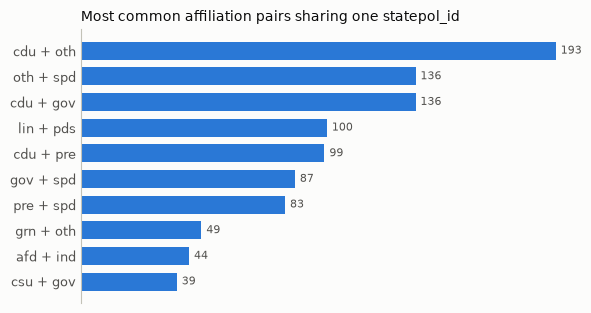

In [16]:
shared = linked[linked["statepol_id"].duplicated(keep=False)]
n_aff = shared.groupby("statepol_id")["affiliation"].nunique()
print(f"statepol_ids with more than one mandate: {len(n_aff):,}")
print(f"  same affiliation (name variants): {(n_aff == 1).sum():,}")
print(f"  different affiliations: {(n_aff > 1).sum():,}")

combos = (shared[shared["statepol_id"].isin(n_aff[n_aff > 1].index)]
          .groupby("statepol_id")["affiliation"].apply(lambda a: " + ".join(sorted(a)))
          .value_counts().head(10).iloc[::-1])
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.barh(combos.index, combos.values, color=NAVY, height=0.7)
for y, v in enumerate(combos.values):
    ax.text(v + 2, y, str(v), va="center", color=CHROME["ink_secondary"], fontsize=8)
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_title("Most common affiliation pairs sharing one statepol_id", loc="left", fontsize=10)
fig.tight_layout()
plt.show()

## AfD mandates per state and period

Counts distinct mandates, not seats. Name variants, successors and double roles all add mandates.
Columns are the state's 1st, 2nd and 3rd period with AfD mandates.

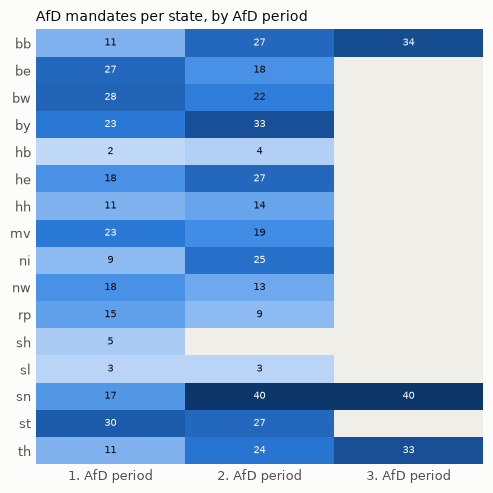

In [17]:
afd_mandates = mandates[mandates["affiliation"] == "afd"].groupby(["state", "period"]).size().reset_index(name="n")
afd_mandates["afd_period"] = afd_mandates.groupby("state")["period"].rank().astype(int)
afd_grid = afd_mandates.pivot(index="state", columns="afd_period", values="n")
afd_grid.columns = [f"{c}. AfD period" for c in afd_grid.columns]
heatmap(afd_grid, "AfD mandates per state, by AfD period", fmt="{:.0f}", vmax=afd_grid.max().max(), figsize=(5, 5))

The first period with AfD mandates should be the period that starts on the state's AfD entry date.

In [18]:
period_start = (paragraphs.assign(date=pd.to_datetime(paragraphs["date"]))
                .groupby(["state", "period"])["date"].min().rename("entry_date").reset_index())
entry_period = afd_dates.merge(period_start, on=["state", "entry_date"]).set_index("state")["period"]
first_afd_period = mandates[mandates["affiliation"] == "afd"].groupby("state")["period"].min()

mismatches = (entry_period != first_afd_period).sum()
print(f"States checked: {len(entry_period)}, mismatches: {mismatches}")

States checked: 16, mismatches: 0


## Integrity checks

Speech paragraphs whose `mandate_id` is missing from the mandates table. Most are spelling variants of a name that is in the table.

In [19]:
orphans = speech[~speech["mandate_id"].isin(mandates["mandate_id"])]
print(f"Speech paragraphs with unknown mandate_id: {len(orphans):,}")
print(orphans["affiliation"].value_counts().head())
orphans["mandate_id"].value_counts().head(10)

Speech paragraphs with unknown mandate_id: 1,593
affiliation
spd    1089
cdu     397
afd      81
grn      14
dvu      12
Name: count, dtype: int64


mandate_id
ni_15_spd_claus-johannßen        436
th_4_cdu_krause                  310
hh_18_spd_rolf-dieter-kloos      287
hh_17_spd_rolf-dieter-kloos      132
hh_16_spd_rolf-dieter-kloos      109
hh_19_spd_rolf-dieter-klooß       94
th_8_afd_hauser                   81
hb_20_cdu_oguzhan-yazıcı          42
nw_17_cdu_christian-untrießer     34
be_17_spd_ilkin-ozisik            31
Name: count, dtype: int64

v3 renamed the affiliation code `ijn` to `nsc` (codebook, version history). The mandates table still has one empty `ijn` placeholder
row per state and period. No paragraph points to them, and `nsc` paragraphs have an empty `mandate_id`. An upstream leftover, safe to ignore.

In [20]:
ijn = mandates[mandates["affiliation"] == "ijn"]
n_state_periods = paragraphs.groupby("state")["period"].nunique().sum()
print(f"ijn rows: {len(ijn)} (state-periods in the corpus: {n_state_periods})")
print(f"Paragraphs pointing to them: {paragraphs['mandate_id'].isin(ijn['mandate_id']).sum()}")
print(f"nsc mandates in the table: {(mandates['affiliation'] == 'nsc').sum()}")

ijn rows: 99 (state-periods in the corpus: 99)


Paragraphs pointing to them: 0
nsc mandates in the table: 0
